# Causal Data Generation

This notebook generates a reproducible semi-synthetic customer-retention dataset with:

- observed customer characteristics,
- non-random treatment assignment,
- known propensity scores,
- potential outcomes under treatment and no treatment,
- heterogeneous individual treatment effects,
- and an observed outcome affected by confounding.

In [2]:
import sys

print("Python executable:", sys.executable)

Python executable: d:\article28-unet-projects\predictive-vs-causal-decision-lab\.venv\Scripts\python.exe


In [3]:
import numpy as np
import pandas as pd
from scipy.special import expit


RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

n = 6000

age = np.clip(
    rng.normal(loc=44, scale=12, size=n),
    18,
    80,
)

tenure = np.clip(
    rng.gamma(shape=2.2, scale=18, size=n),
    1,
    144,
)

spend = np.clip(
    rng.lognormal(mean=4.1, sigma=0.45, size=n),
    15,
    400,
)

complaints = np.clip(
    rng.poisson(lam=1.6, size=n),
    0,
    8,
)

satisfaction = rng.beta(
    a=4.0,
    b=2.2,
    size=n,
)

engagement = rng.beta(
    a=2.7,
    b=2.4,
    size=n,
)

region = rng.choice(
    ["North", "South", "East", "West"],
    size=n,
)

df = pd.DataFrame(
    {
        "age": age,
        "tenure": tenure,
        "spend": spend,
        "complaints": complaints,
        "satisfaction": satisfaction,
        "engagement": engagement,
        "region": region,
    }
)

print("Dataset shape:", df.shape)
print("Total missing values:", df.isna().sum().sum())

display(df.head())

Dataset shape: (6000, 7)
Total missing values: 0


,age,tenure,spend,complaints,satisfaction,engagement,region
0,47.656605,39.445856,80.538653,1,0.739655,0.149673,South
1,31.520191,59.643340,124.772237,0,0.621712,0.503829,West
2,53.005414,14.470515,55.084554,0,0.748244,0.878509,South
3,55.286777,29.174800,50.544936,1,0.754126,0.605190,East
4,20.587578,7.246782,47.698135,2,0.532050,0.356345,North


## 2. Treatment Assignment and Potential Outcomes

In this section, we simulate:

- non-random treatment assignment,
- the probability of receiving treatment,
- outcomes under no treatment and treatment,
- heterogeneous treatment effects,
- and the observed outcome.

In [4]:
high_complaints = (df["complaints"] >= 2).astype(int)

treatment_logit = (
    -0.35
    + 0.65 * high_complaints
    - 0.95 * df["satisfaction"]
    - 0.55 * df["engagement"]
)

true_propensity = np.clip(
    expit(treatment_logit),
    0.04,
    0.96,
)

treatment = rng.binomial(
    n=1,
    p=true_propensity,
)

df["high_complaints"] = high_complaints
df["true_propensity"] = true_propensity
df["treatment"] = treatment

print("Treatment rate:", df["treatment"].mean())
print("Minimum propensity:", df["true_propensity"].min())
print("Maximum propensity:", df["true_propensity"].max())

display(
    df[
        [
            "complaints",
            "satisfaction",
            "engagement",
            "high_complaints",
            "true_propensity",
            "treatment",
        ]
    ].head()
)

Treatment rate: 0.283
Minimum propensity: 0.14344366433372507
Maximum propensity: 0.5202238593995924


,complaints,satisfaction,engagement,high_complaints,true_propensity,treatment
0,1,0.739655,0.149673,0,0.243241,0
1,0,0.621712,0.503829,0,0.228336,0
2,0,0.748244,0.878509,0,0.175953,1
3,1,0.754126,0.605190,0,0.197931,1
4,2,0.532050,0.356345,1,0.400967,0


In [5]:
low_engagement = (df["engagement"] < 0.40).astype(int)
high_satisfaction = (df["satisfaction"] > 0.82).astype(int)

baseline_logit = (
    -0.55
    + 0.55 * df["satisfaction"]
    + 0.75 * df["engagement"]
    - 0.38 * df["complaints"]
)

effect_logit = (
    0.20
    + 0.75 * df["high_complaints"]
    + 0.60 * low_engagement
    - 0.30 * high_satisfaction
)

p0 = expit(baseline_logit)
p1 = expit(baseline_logit + effect_logit)

true_cate = p1 - p0

df["low_engagement"] = low_engagement
df["high_satisfaction"] = high_satisfaction
df["p0"] = p0
df["p1"] = p1
df["true_cate"] = true_cate

print("Mean probability without treatment:", df["p0"].mean())
print("Mean probability with treatment:", df["p1"].mean())
print("True average treatment effect:", df["true_cate"].mean())

display(
    df[
        [
            "satisfaction",
            "engagement",
            "complaints",
            "p0",
            "p1",
            "true_cate",
        ]
    ].head()
)

Mean probability without treatment: 0.4064169696025979
Mean probability with treatment: 0.5647815830401393
True average treatment effect: 0.1583646134375414


,satisfaction,engagement,complaints,p0,p1,true_cate
0,0.739655,0.149673,1,0.398688,0.596058,0.197370
1,0.621712,0.503829,0,0.542352,0.591414,0.049062
2,0.748244,0.878509,0,0.627245,0.672699,0.045454
3,0.754126,0.605190,1,0.484670,0.534610,0.049940
4,0.532050,0.356345,2,0.320797,0.689950,0.369154


In [6]:
u = rng.uniform(size=n)

y0 = (u < p0).astype(int)
y1 = (u < p1).astype(int)

outcome = np.where(
    treatment == 1,
    y1,
    y0,
)

df["y0"] = y0
df["y1"] = y1
df["outcome"] = outcome

print("Renewal rate without treatment:", df["y0"].mean())
print("Renewal rate with treatment:", df["y1"].mean())
print("Observed renewal rate:", df["outcome"].mean())
print("True outcome-scale ATE:", (df["y1"] - df["y0"]).mean())

display(
    df[
        [
            "treatment",
            "p0",
            "p1",
            "y0",
            "y1",
            "outcome",
        ]
    ].head(10)
)

Renewal rate without treatment: 0.407
Renewal rate with treatment: 0.5558333333333333
Observed renewal rate: 0.45516666666666666
True outcome-scale ATE: 0.14883333333333335


,treatment,p0,p1,y0,y1,outcome
0,0,0.398688,0.596058,0,0,0
1,0,0.542352,0.591414,0,0,0
2,1,0.627245,0.672699,0,0,0
3,1,0.484670,0.534610,0,0,0
4,0,0.320797,0.689950,0,0,0
5,0,0.430995,0.661997,1,1,1
6,0,0.433922,0.483539,1,1,1
7,0,0.406516,0.603869,1,1,1
8,0,0.441335,0.565682,1,1,1
9,0,0.562444,0.610898,1,1,1


In [7]:
df["individual_effect"] = df["y1"] - df["y0"]

helped = (df["individual_effect"] == 1).sum()
unaffected = (df["individual_effect"] == 0).sum()
harmed = (df["individual_effect"] == -1).sum()

consistency_check = (
    df["outcome"]
    == np.where(df["treatment"] == 1, df["y1"], df["y0"])
).all()

print("Customers helped by treatment:", helped)
print("Customers unaffected by treatment:", unaffected)
print("Customers harmed by treatment:", harmed)
print("Mean individual treatment effect:", df["individual_effect"].mean())
print("Observed outcome consistency check:", consistency_check)

Customers helped by treatment: 904
Customers unaffected by treatment: 5085
Customers harmed by treatment: 11
Mean individual treatment effect: 0.14883333333333335
Observed outcome consistency check: True


In [8]:
harmed_customers = df.loc[
    df["individual_effect"] == -1,
    [
        "satisfaction",
        "engagement",
        "complaints",
        "high_satisfaction",
        "low_engagement",
        "high_complaints",
        "p0",
        "p1",
        "true_cate",
        "y0",
        "y1",
    ],
]

print("Number of harmed customers:", len(harmed_customers))

print(
    "All have high satisfaction:",
    harmed_customers["high_satisfaction"].eq(1).all(),
)

print(
    "None have high complaints:",
    harmed_customers["high_complaints"].eq(0).all(),
)

print(
    "None have low engagement:",
    harmed_customers["low_engagement"].eq(0).all(),
)

display(harmed_customers.head())

Number of harmed customers: 11
All have high satisfaction: True
None have high complaints: True
None have low engagement: True


,satisfaction,engagement,complaints,high_satisfaction,low_engagement,high_complaints,p0,p1,true_cate,y0,y1
67,0.917530,0.517025,0,1,0,0,0.584776,0.560308,-0.024468,1,0
95,0.981273,0.526141,0,1,0,0,0.594911,0.570602,-0.024310,1,0
476,0.845226,0.946564,0,1,0,0,0.651309,0.628269,-0.023040,1,0
985,0.846185,0.614110,1,1,0,0,0.498996,0.474019,-0.024977,1,0
2361,0.915636,0.562024,0,1,0,0,0.592695,0.568349,-0.024346,1,0


## 3. Causal Data-Generating Process

The following directed acyclic graph (DAG) represents the assumed causal structure.

- Satisfaction, engagement, and complaints affect treatment assignment.
- These variables also affect the renewal outcome.
- Treatment directly affects the renewal outcome.
- Therefore, satisfaction, engagement, and complaints are confounders.

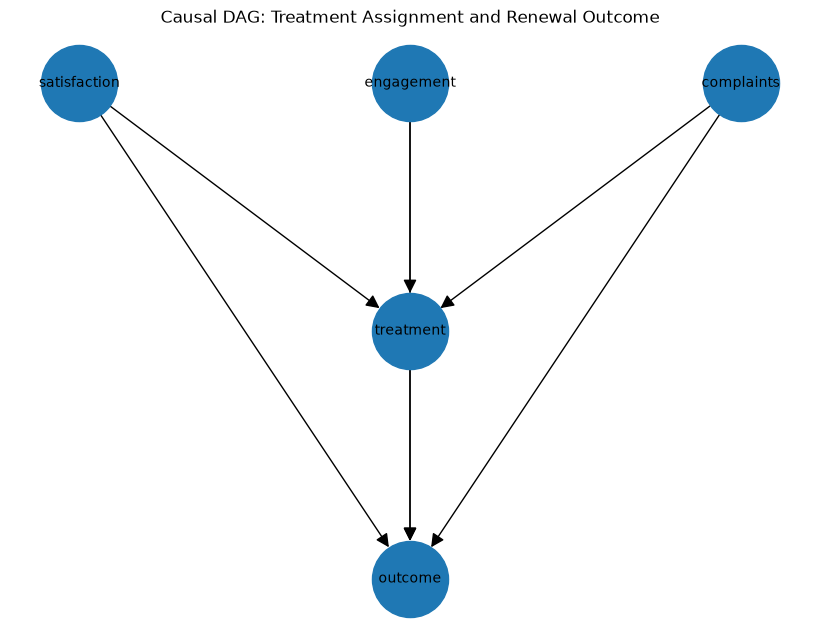

Project root: D:\article28-unet-projects\predictive-vs-causal-decision-lab
DAG saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\figures\causal_dag.png
File exists: True


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx


current_path = Path.cwd().resolve()

if (current_path / "README.md").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


dag = nx.DiGraph()

edges = [
    ("satisfaction", "treatment"),
    ("engagement", "treatment"),
    ("complaints", "treatment"),
    ("satisfaction", "outcome"),
    ("engagement", "outcome"),
    ("complaints", "outcome"),
    ("treatment", "outcome"),
]

dag.add_edges_from(edges)


positions = {
    "satisfaction": (-2, 1),
    "engagement": (0, 1),
    "complaints": (2, 1),
    "treatment": (0, 0),
    "outcome": (0, -1),
}


plt.figure(figsize=(8, 6))

nx.draw(
    dag,
    pos=positions,
    with_labels=True,
    node_size=3000,
    arrowsize=20,
    font_size=10,
)

plt.title("Causal DAG: Treatment Assignment and Renewal Outcome")

dag_path = FIGURES_DIR / "causal_dag.png"

plt.savefig(
    dag_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Project root:", PROJECT_ROOT)
print("DAG saved to:", dag_path)
print("File exists:", dag_path.exists())

## 4. Save Generated Datasets

Two datasets are saved:

- an observed dataset for model development,
- a full dataset containing the known causal ground truth for evaluation.

Ground-truth variables must not be used as model inputs.

In [12]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


observed_columns = [
    "age",
    "tenure",
    "spend",
    "complaints",
    "satisfaction",
    "engagement",
    "region",
    "treatment",
    "outcome",
]


observed_path = (
    PROCESSED_DIR
    / "customer_retention_observed.csv"
)

full_path = (
    PROCESSED_DIR
    / "customer_retention_full.csv"
)


df[observed_columns].to_csv(
    observed_path,
    index=False,
)

df.to_csv(
    full_path,
    index=False,
)


observed_check = pd.read_csv(observed_path)
full_check = pd.read_csv(full_path)


print("Observed dataset shape:", observed_check.shape)
print("Full dataset shape:", full_check.shape)

print(
    "Observed missing values:",
    observed_check.isna().sum().sum(),
)

print(
    "Full missing values:",
    full_check.isna().sum().sum(),
)

print("Observed dataset saved to:", observed_path)
print("Full dataset saved to:", full_path)

print("Observed file exists:", observed_path.exists())
print("Full file exists:", full_path.exists())

Observed dataset shape: (6000, 9)
Full dataset shape: (6000, 19)
Observed missing values: 0
Full missing values: 0
Observed dataset saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\data\processed\customer_retention_observed.csv
Full dataset saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\data\processed\customer_retention_full.csv
Observed file exists: True
Full file exists: True


In [13]:
assert df.shape == (6000, 19)
assert df.isna().sum().sum() == 0

assert set(df["treatment"].unique()).issubset({0, 1})
assert set(df["outcome"].unique()).issubset({0, 1})
assert set(df["y0"].unique()).issubset({0, 1})
assert set(df["y1"].unique()).issubset({0, 1})

assert df["true_propensity"].between(0, 1).all()
assert df["p0"].between(0, 1).all()
assert df["p1"].between(0, 1).all()

assert np.allclose(
    df["true_cate"],
    df["p1"] - df["p0"],
)

assert (
    df["outcome"]
    == np.where(
        df["treatment"] == 1,
        df["y1"],
        df["y0"],
    )
).all()

print("All causal data validation checks passed.")

All causal data validation checks passed.
